# Phase-space embedding and parameter selection

This notebook demonstrates the `nolitisea.embedding` module.  Before a scalar
time series can be analysed with nonlinear tools it must be reconstructed in
phase space (Takens' delay embedding), which requires two parameters: the
**time delay** `tau` and the **embedding dimension** `m`.  The module provides
classical estimators for both, plus Poincare-section analysis of the
reconstructed orbit:

| # | Routine | Estimates | Returns |
|---|---------|-----------|---------|
| 1 | `mutual.embedded_mutual_information` / `mutual.first_minimum` | time delay `tau` (Fraser & Swinney) | MI curve and its first local minimum |
| 2 | `mutual.matrix_renyi_mutual_information` | time delay `tau` (kernel/Renyi estimator) | MI value per lag pair |
| 3 | `c_c.cc_method` | time delay `tau`, embedding window `t_w`, dimension `m` | C-C statistics and parameters |
| 4 | `false_nearest.kennel_method` | minimum embedding dimension (Kennel FNN) | false-nearest fraction per dimension |
| 5 | `false_nearest.cao_method` | minimum embedding dimension (Cao E1/E2) | `E`, `Es` per dimension |
| 6 | `poincare.poincare_section` | geometry of threshold crossings | section points and return times |

The running example is the x-component of a Lorenz trajectory (true embedding
dimension 3), so the estimators should agree on `tau` of a few samples and a
minimum dimension of 3-4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.embedding.c_c import cc_method
from nolitisea.embedding.false_nearest import cao_method, kennel_method
from nolitisea.embedding.mutual import (
    embedded_mutual_information,
    first_minimum,
    matrix_renyi_mutual_information,
)
from nolitisea.embedding.poincare import poincare_section
from nolitisea.generate.lorenz import lorenz

# Lorenz trajectory sampled at dt = 0.03; analyse the x-component.
t, states = lorenz(length=10000)
x = states[:, 0]

print(f"states: shape {states.shape}, dt = {t[1] - t[0]:.3f}")
print(f"x: range [{x.min():.3f}, {x.max():.3f}]")

states: shape (10000, 3), dt = 0.030
x: range [-18.976, 19.206]


## 1. `mutual` — delay selection via mutual information

The first minimum of the time-delayed mutual information
`I(x(t); x(t + tau))` is the classical delay estimate (Fraser & Swinney 1986):
at that lag the delayed samples add maximal *new* information to the
reconstruction.

`embedded_mutual_information(series, max_lag)` computes the curve for lags
`0 .. max_lag` with an equi-width histogram estimator (Shannon MI in bits;
`mi[0]` equals the marginal entropy `H(x)`), and `first_minimum` returns the
lag of the first local minimum.

In [2]:
max_lag = 100
mi = embedded_mutual_information(x, max_lag=max_lag)
tau_mi = first_minimum(x, max_lag=max_lag)

print(f"MI curve: length {mi.size} (lags 0..{max_lag})")
print(f"mi[0] = marginal entropy H(x) = {mi[0]:.3f} bits")
print(f"first local minimum of MI at tau = {tau_mi}")

MI curve: length 101 (lags 0..100)
mi[0] = marginal entropy H(x) = 3.711 bits
first local minimum of MI at tau = 6


### Mutual information vs lag

The curve decays from the marginal entropy and oscillates; the first local
minimum (marked in red) selects the embedding delay.

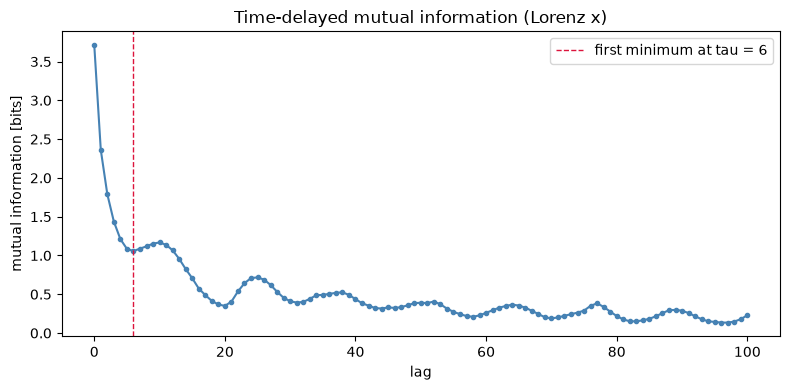

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(max_lag + 1), mi, "-o", ms=3, color="steelblue")
ax.axvline(tau_mi, color="crimson", ls="--", lw=1,
           label=f"first minimum at tau = {tau_mi}")
ax.set_xlabel("lag")
ax.set_ylabel("mutual information [bits]")
ax.set_title("Time-delayed mutual information (Lorenz x)")
ax.legend()
plt.tight_layout()
plt.show()

### Kernel Renyi mutual information — an alternative estimator

`matrix_renyi_mutual_information(x, y)` estimates MI directly from the
eigenspectrum of Gaussian kernel matrices (Sanchez Giraldo et al. 2014),
avoiding histogram binning entirely.  Comparing the two estimators on the
same lag range is a useful consistency check: the kernel curve follows the
same overall shape, though its local-minimum structure is coarser and it
decays towards zero at long lags (a known bias of the kernel estimator for
weakly dependent data).  (The kernel estimator needs equal-length inputs, so
the lagged slices are aligned explicitly, and it uses kernel matrices of
size `n x n`, so we subsample the series.)

In [4]:
xs = x[:2000]
lags_r = np.arange(0, 42, 2)
mi_renyi = []
for tau_r in lags_r:
    x1 = xs[:-tau_r] if tau_r else xs
    x2 = xs[tau_r : tau_r + len(x1)]
    mi_renyi.append(matrix_renyi_mutual_information(x1, x2))
mi_renyi = np.array(mi_renyi)

# First local minimum of the Renyi curve (if one exists on this range).
d1 = np.diff(mi_renyi)
loc_min = np.where((d1[:-1] < 0) & (d1[1:] > 0))[0] + 1
if loc_min.size:
    print(f"Renyi MI: first local minimum at lag {lags_r[loc_min[0]]}")
else:
    print("Renyi MI: no interior local minimum on the scanned lag range")
print(f"(Shannon estimate was tau = {tau_mi})")

Renyi MI: first local minimum at lag 18
(Shannon estimate was tau = 6)


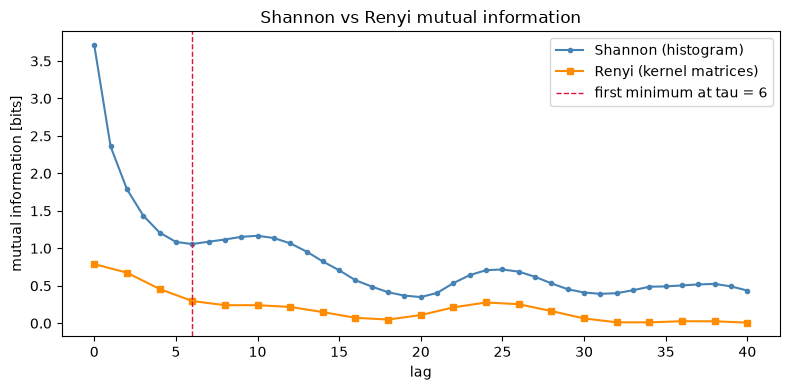

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(41), mi[:41], "-o", ms=3, color="steelblue",
        label="Shannon (histogram)")
ax.plot(lags_r, mi_renyi, "-s", ms=4, color="darkorange",
        label="Renyi (kernel matrices)")
ax.axvline(tau_mi, color="crimson", ls="--", lw=1,
           label=f"first minimum at tau = {tau_mi}")
ax.set_xlabel("lag")
ax.set_ylabel("mutual information [bits]")
ax.set_title("Shannon vs Renyi mutual information")
ax.legend()
plt.tight_layout()
plt.show()

## 2. `c_c` — the C-C method (delay, window and dimension at once)

The C-C method (Kim et al. 1999) scans candidate delays `t = 1 .. max_t` and
computes three statistics from correlation integrals: `S_mean(t)`,
`delta_S(t)` and their combination `S_cor(t)`.  It then reads off

- `tau`  — the first local minimum of `delta_S(t)`,
- `t_w`  — the embedding window, the global minimum of `S_cor(t)`,
- `m`    — the dimension estimate `round(t_w / tau) + 1`.

This gives all three embedding parameters from a single pass.

In [6]:
cc = cc_method(x, max_t=50, n_jobs=-1)

print(f"tau (first local min of delta_S) = {cc['tau']}")
print(f"t_w (global min of S_cor)        = {cc['t_w']}")
print(f"m  (round(t_w / tau) + 1)        = {cc['m']}")
print(f"(MI estimate was tau = {tau_mi})")

tau (first local min of delta_S) = 6
t_w (global min of S_cor)        = 30
m  (round(t_w / tau) + 1)        = 6
(MI estimate was tau = 6)


### C-C statistics vs candidate delay

The three curves over the scanned delay range; the chosen `tau` and `t_w`
are marked.

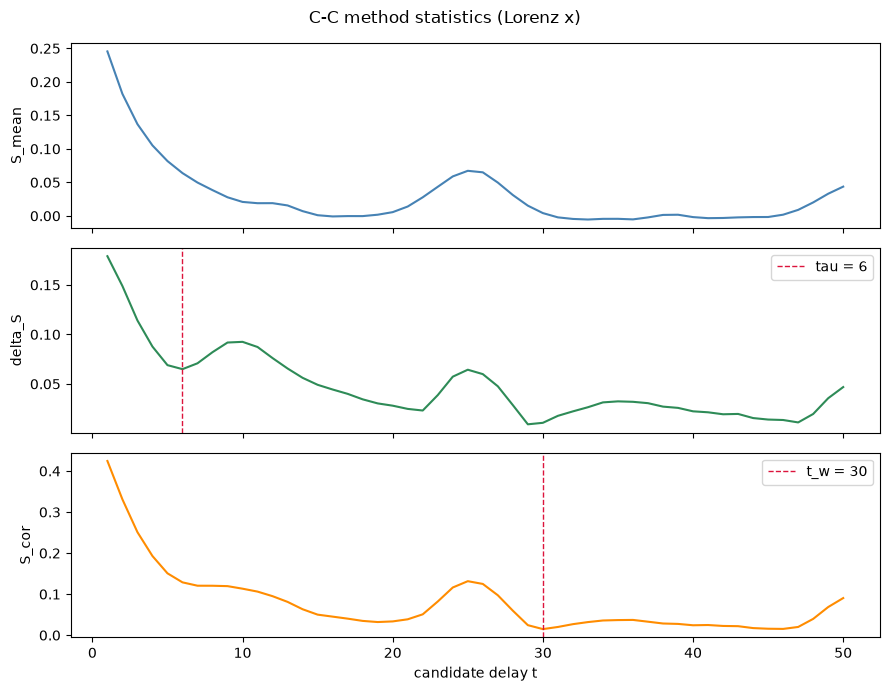

In [7]:
tt = np.arange(1, len(cc["S_mean"]) + 1)
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].plot(tt, cc["S_mean"], color="steelblue")
axes[0].set_ylabel("S_mean")
axes[1].plot(tt, cc["delta_S"], color="seagreen")
axes[1].axvline(cc["tau"], color="crimson", ls="--", lw=1,
                label=f"tau = {cc['tau']}")
axes[1].set_ylabel("delta_S")
axes[1].legend()
axes[2].plot(tt, cc["S_cor"], color="darkorange")
axes[2].axvline(cc["t_w"], color="crimson", ls="--", lw=1,
                label=f"t_w = {cc['t_w']}")
axes[2].set_ylabel("S_cor")
axes[2].set_xlabel("candidate delay t")
axes[2].legend()

fig.suptitle("C-C method statistics (Lorenz x)")
plt.tight_layout()
plt.show()

## 3. `false_nearest` — minimum embedding dimension

Two classical estimators:

- **Kennel's false-nearest-neighbours method** (`kennel_method`): embed with
  dimension `m`, find each point's nearest neighbour, and flag the pair as
  *false* if the extra coordinate in dimension `m + 1` separates them too
  much (test I, `R_tol`) or if the full distance exceeds `A_tol` standard
  deviations (test II).  The fraction of false neighbours is reported per
  dimension as `f1` (test I), `f2` (test II) and `f3` (either test); the
  minimum embedding dimension is where the fraction drops to (near) zero.
- **Cao's method** (`cao_method`): computes the mean magnification `E(d)` of
  neighbour distances from `d` to `d + 1`; the ratio `E1(d) = E(d+1)/E(d)`
  stops growing at the minimum embedding dimension, and `E2(d)` distinguishes
  deterministic from random data.

A Theiler window (`theiler=2`) excludes temporally correlated neighbours.

In [8]:
fnn = kennel_method(x, min_emb=1, max_emb=8, delay=tau_mi, theiler=2)

print("dim   f1      f2      f3")
for d in sorted(fnn):
    k = fnn[d]
    print(f" {d}   {k['f1']:.4f}  {k['f2']:.4f}  {k['f3']:.4f}")

dim   f1      f2      f3
 1   0.9940  0.0125  0.9940
 2   0.0882  0.0000  0.0882
 3   0.0019  0.0000  0.0019
 4   0.0000  0.0000  0.0000
 5   0.0000  0.0000  0.0000
 6   0.0000  0.0004  0.0004
 7   0.0000  0.0005  0.0005
 8   0.0000  0.0005  0.0005


### False-nearest fraction vs dimension

`f3` is large at dimension 1, drops sharply through dimensions 2-3 and
collapses to (almost) zero beyond the minimum embedding dimension — matching
the known dimension of the Lorenz attractor.  The exact crossing dimension
depends on the trajectory and the chosen delay; read the smallest `m` at
which the fraction falls below a small tolerance (e.g. 1%).

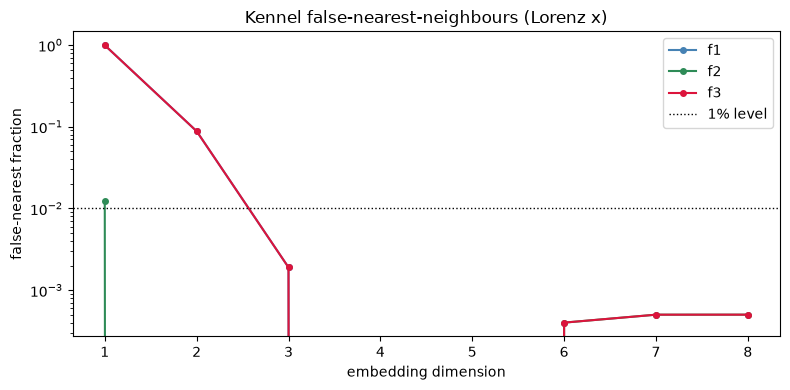

In [9]:
dims = sorted(fnn)
fig, ax = plt.subplots(figsize=(8, 4))
for key, color in (("f1", "steelblue"), ("f2", "seagreen"), ("f3", "crimson")):
    ax.semilogy(dims, [fnn[d][key] for d in dims], "-o", ms=4,
                color=color, label=key)
ax.axhline(0.01, color="k", ls=":", lw=1, label="1% level")
ax.set_xlabel("embedding dimension")
ax.set_ylabel("false-nearest fraction")
ax.set_title("Kennel false-nearest-neighbours (Lorenz x)")
ax.legend()
plt.tight_layout()
plt.show()

### Cao's E1 / E2 ratios

`E1` rising towards 1 and plateauing indicates the minimum embedding
dimension; `E2` clearly above 1 confirms the data are deterministic rather
than random.  (`E1(2) ≈ 0` here is an artefact of duplicate near-neighbours
in a 1-dimensional embedding.)

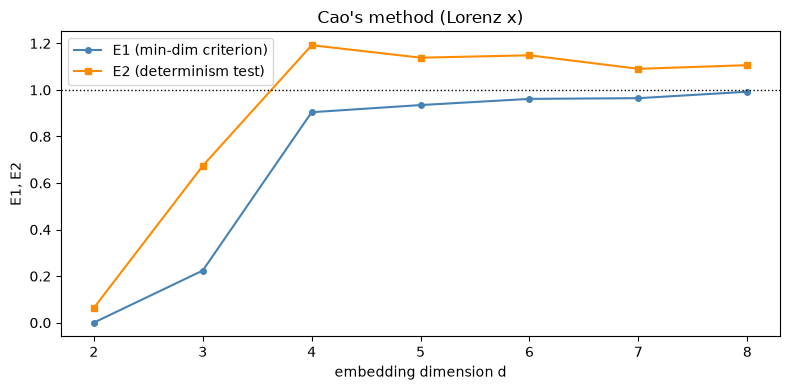

In [10]:
cao = cao_method(x, min_emb=1, max_emb=8, delay=tau_mi, theiler=2)
dims_c = sorted(cao)
E = np.array([cao[d][0] for d in dims_c])
Es = np.array([cao[d][1] for d in dims_c])
E1 = E[1:] / E[:-1]
E2 = Es[1:] / Es[:-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dims_c[1:], E1, "-o", ms=4, color="steelblue",
        label="E1 (min-dim criterion)")
ax.plot(dims_c[1:], E2, "-s", ms=4, color="darkorange",
        label="E2 (determinism test)")
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_xlabel("embedding dimension d")
ax.set_ylabel("E1, E2")
ax.set_title("Cao's method (Lorenz x)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. `poincare` — Poincare sections of the reconstructed orbit

`poincare_section(series, dim, delay, ...)` scans the (delay-reconstructed)
trajectory for upward (`direction=0`) or downward (`direction=1`) crossings
of a threshold in the monitored component (default: the last embedded
component; default threshold: the series mean).  Each crossing time is
linearly interpolated and the remaining components are interpolated to the
same instant, giving one section point of dimension `dim - 1` per crossing,
together with the return time since the previous crossing.

Return times of a deterministic system concentrate near the dominant orbital
period — a useful check of the reconstruction.

In [11]:
pts, rts = poincare_section(x, dim=3, delay=tau_mi, direction=0)

print(f"section points: {pts.shape} (dim - 1 = 2 coordinates each)")
print(f"return times  : {rts.shape}")
print(f"mean return time = {rts.mean():.2f} samples "
      f"(= {rts.mean() * (t[1] - t[0]):.3f} time units)")

section points: (93, 2) (dim - 1 = 2 coordinates each)
return times  : (93,)
mean return time = 106.17 samples (= 3.185 time units)


### Section points and return times

Left: the section points of the reconstructed Lorenz orbit in the cutting
plane.  Right: return times of successive crossings, clustering around the
dominant orbital period.

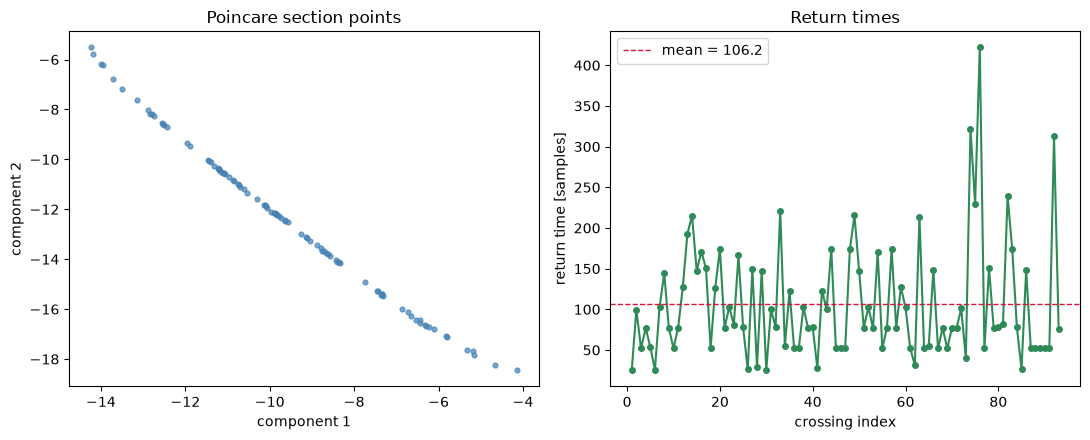

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(pts[:, 0], pts[:, 1], s=12, c="steelblue", alpha=0.7)
axes[0].set_xlabel("component 1")
axes[0].set_ylabel("component 2")
axes[0].set_title("Poincare section points")

axes[1].plot(np.arange(1, len(rts) + 1), rts, "-o", ms=4,
             color="seagreen")
axes[1].axhline(rts.mean(), color="crimson", ls="--", lw=1,
                label=f"mean = {rts.mean():.1f}")
axes[1].set_xlabel("crossing index")
axes[1].set_ylabel("return time [samples]")
axes[1].set_title("Return times")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

`nolitisea.embedding` covers the full parameter-selection workflow for delay
reconstruction:

| Step | Routines | Lorenz x result |
|------|----------|-----------------|
| delay `tau` | `mutual.first_minimum`, `c_c.cc_method` | a few samples, consistent between estimators |
| window + dimension | `c_c.cc_method` | `t_w`, `m = round(t_w / tau) + 1` |
| minimum dimension | `false_nearest.kennel_method`, `false_nearest.cao_method` | 3-4 (FNN fraction collapses to 0) |
| orbit geometry | `poincare.poincare_section` | section points + return times |

The delay estimates of the MI and C-C methods agree closely, the
false-neighbour fractions recover the known minimum dimension of the Lorenz
attractor, and the return times of the Poincare section concentrate around
the dominant orbital period.  Together these tools turn a raw scalar series
into the `(tau, m)` pair that the downstream analysis routines expect.